In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

In [2]:
model = joblib.load("models/heart_best_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
df = pd.read_csv("data/heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 918
Columns : 12


In [5]:
X = df.drop("HeartDisease", axis=1)

y = df["HeartDisease"]

print(X.shape)
print(y.shape)

(918, 11)
(918,)


In [6]:
sample = pd.DataFrame({
    "Age":[40],
    "Sex":["M"],
    "ChestPainType":["ATA"],
    "RestingBP":[120],
    "Cholesterol":[200],
    "FastingBS":[0],
    "RestingECG":["Normal"],
    "MaxHR":[170],
    "ExerciseAngina":["N"],
    "Oldpeak":[0.0],
    "ST_Slope":["Up"]

})

sample

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,120,200,0,Normal,170,N,0.0,Up


In [7]:
prediction = model.predict(sample)

prediction

array([0])

In [8]:
probability = model.predict_proba(sample)

probability

array([[0.9958725 , 0.00412751]], dtype=float32)

In [9]:
risk_percentage = probability[0][1] * 100

print(f"Heart Disease Risk: {risk_percentage:.2f}%")

Heart Disease Risk: 0.41%


In [10]:
if risk_percentage < 30:

    print("Low Risk")

elif risk_percentage < 70:

    print("Moderate Risk")

else:

    print("High Risk")

Low Risk


In [11]:
batch_data = X.head(10)

batch_data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up


In [12]:
predictions = model.predict(batch_data)

predictions

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [13]:
probabilities = model.predict_proba(batch_data)

probabilities[:5]

array([[0.9797861 , 0.02021391],
       [0.8383733 , 0.16162668],
       [0.98719704, 0.01280293],
       [0.06647056, 0.93352944],
       [0.9739006 , 0.02609937]], dtype=float32)

In [14]:
result_df = batch_data.copy()

result_df["Prediction"] = predictions

result_df["Risk_Probability"] = (probabilities[:,1] * 100)

result_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Prediction,Risk_Probability
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,2.021391
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,0,16.162668
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,1.280293
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,93.352943
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,2.609936


In [15]:
def risk_level(prob):

    if prob < 30:
        return "Low"

    elif prob < 70:
        return "Moderate"

    else:
        return "High"


result_df["Risk_Level"] = (result_df["Risk_Probability"].apply(risk_level))

result_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Prediction,Risk_Probability,Risk_Level
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,2.021391,Low
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,0,16.162668,Low
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,1.280293,Low
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,93.352943,High
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,2.609936,Low


In [16]:
result_df["Prediction"].value_counts()

Prediction
0    8
1    2
Name: count, dtype: int64

In [17]:
result_df.to_csv("Data/predictions.csv", index=False)

print("Predictions Saved Successfully")

Predictions Saved Successfully


In [18]:
all_predictions = model.predict(X)

all_predictions[:10]

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, all_predictions)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9542


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y,all_predictions))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       410
           1       0.96      0.96      0.96       508

    accuracy                           0.95       918
   macro avg       0.95      0.95      0.95       918
weighted avg       0.95      0.95      0.95       918



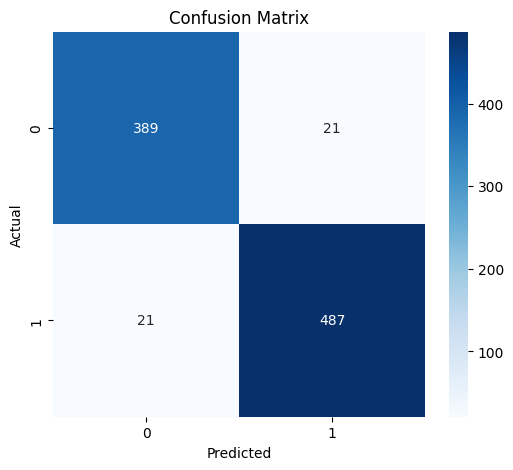

In [21]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, all_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
custom_patient = pd.DataFrame({

    "Age":[65],
    "Sex":["M"],
    "ChestPainType":["ASY"],
    "RestingBP":[150],
    "Cholesterol":[280],
    "FastingBS":[1],
    "RestingECG":["ST"],
    "MaxHR":[120],
    "ExerciseAngina":["Y"],
    "Oldpeak":[2.5],
    "ST_Slope":["Flat"]

})

custom_patient

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,65,M,ASY,150,280,1,ST,120,Y,2.5,Flat


In [23]:
prediction = model.predict(custom_patient)[0]

probability = model.predict_proba(custom_patient)[0][1]

print("Prediction:", prediction)

print(f"Risk Probability: {probability*100:.2f}%")

Prediction: 1
Risk Probability: 99.64%


In [24]:
if prediction == 1:

    print(f"⚠️ High Risk of Heart Disease ({probability*100:.2f}%)")

else:

    print( f"✅ Low Risk of Heart Disease ({probability*100:.2f}%)")

⚠️ High Risk of Heart Disease (99.64%)


In [25]:
print("="*50)

print("Prediction Pipeline Completed")

print("="*50)

print("Model Loaded Successfully")
print("Single Prediction Tested")
print("Batch Prediction Tested")
print("Custom Patient Tested")
print("Results Exported")

print("="*50)

Prediction Pipeline Completed
Model Loaded Successfully
Single Prediction Tested
Batch Prediction Tested
Custom Patient Tested
Results Exported
